# Engineering of Data Analysis: assignment 1

By delivering this notebook, we confirm that the code presented was developed by the following students.

**Student num:** 67754     **; Name:** Francisco Manuel Nunes Mendes da Costa

**Student num:** 59840     **; Name:** Drey Tengan

**DEADLINE:** 21st April, 23h59

**Only one student should deliver the notebook**


**IMPORTANT:** To use GPUs in Colab, you need to go to the menu ```Edit > Notebook settings``` and select GPU as the hardware accelerator.

Some useful links:
* [ACM DEBS 2015 Grand Challenge](http://www.debs2015.org/call-grand-challenge.html)

* [Spark web site](https://spark.apache.org/)

* [Spark MLlib main page](https://spark.apache.org/mllib/)
* [Spark MLlib guide](https://spark.apache.org/docs/latest/ml-guide.html)

* [CuDF documentation](https://docs.rapids.ai/api/cudf/stable/)
* [cuML documentation](https://docs.rapids.ai/api/cuml/stable/)


# Install software

In [ ]:
# Software to download files
!pip install gdown

In [ ]:
# Install Spark
!apt-get install openjdk-17-jdk-headless
!pip install pyspark==4.0.0.dev2
!mkdir checkpoint


Reading package lists... Done


In [ ]:
# Install RAPIDS - for using cuDF, cuML
# Please read the output of this cell.  If your Colab Instance is not RAPIDS compatible,
# it will warn you and give you remediation steps.
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py


# Setup

The data sets are available in the following link: https://drive.google.com/drive/folders/1WMwLUj0t4Q0GSll96lbF2bDjaPVh1w8z?usp=sharing. For running in Google Colab, you should access the link and Add Shortcut to your Drive.



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# If you added the shortcut to your drive, the file should appear in this directory
# If not, you need to explore from directory /content/drive
!ls /content/drive/MyDrive/Colab\ Notebooks/assignment1

Mounted at /content/drive
sample.csv.gz  sorted_data.csv.gz  tiny.csv.gz


Next cells setup: Pandas, Spark and cuDF/cuML.

In [ ]:
# General imports
import timeit

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.cluster


In [ ]:
# Imports for Spark

import os
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

# imports Spark SQL and Pandas API
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import *
from pyspark.ml.feature import *
import pyspark.pandas as ps

# this sets the maximum number of rows to show when printing pandas Dataframes
ps.set_option('display.max_rows', 10)



/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


In [ ]:
# Imports for cuDF / cuML

import cudf
import cupy as cp
import cuml.cluster

In [ ]:
# Setup the dataset being used

# Large dataset - 12.3 GB compressed
#FILENAME = "/content/drive/MyDrive/Colab Notebooks/assignment1/sorted_data.csv.gz"

# Small dataset - 135 MB compressed
FILENAME = "/content/drive/MyDrive/Colab Notebooks/assignment1/sample.csv.gz"

# Tiny dataset - 6.8 MB compressed (you can use this one for speeding up development only)
#FILENAME = "/content/drive/MyDrive/Colab Notebooks/assignment1/tiny.csv.gz"


In [ ]:
FILENAME

'/content/drive/MyDrive/Colab Notebooks/assignment1/sample.csv.gz'

## Simple statistics

We will print some simple statistics.

In [ ]:
import matplotlib.pyplot as plt
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.linalg import Vectors

spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Assignment 1") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

start_time = time.time()

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")

statistics = spark.sql( """SELECT COUNT( DISTINCT medallion) AS num_medallion,
                                  COUNT( DISTINCT hack_license) AS num_license,
                                  MIN( pickup_datetime) AS min_pickup,
                                  MAX( dropoff_datetime) AS max_dropoff,
                                  MAX( trip_time_in_secs) AS max_trip_time,
                                  MAX( trip_distance) AS max_trip_distance,
                                  MAX( total_amount) AS max_total_amount
                                  FROM data""")
statistics.show()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


+-------------+-----------+-------------------+-------------------+-------------+-----------------+----------------+
|num_medallion|num_license|         min_pickup|        max_dropoff|max_trip_time|max_trip_distance|max_total_amount|
+-------------+-----------+-------------------+-------------------+-------------+-----------------+----------------+
|        10867|      20354|2013-01-01 00:00:00|2013-01-21 00:11:45|        10800|            95.85|           465.0|
+-------------+-----------+-------------------+-------------------+-------------+-----------------+----------------+

Runtime = 21.812875032424927


## Ploting information

Example on how to plot information using matplotlib.

### First plot

This first plot helps showing that data has several invalid values.

Let's plot the pickups.

Plotting pickups


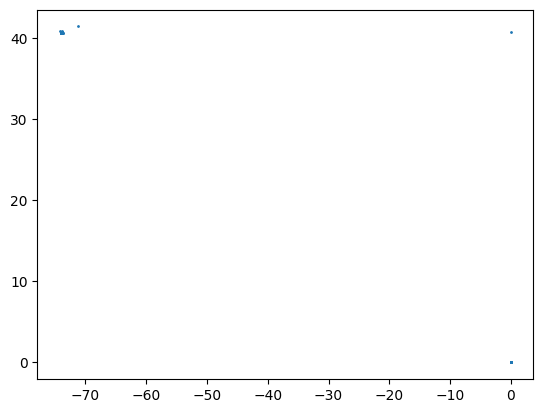

In [ ]:
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Group project") \
    .getOrCreate()

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")

# Plotting all points is probably too much in many computers, so lets plot only a few 1000's
data = spark.sql( "SELECT * FROM data LIMIT 1000")
pickups = data.collect()

print('Plotting pickups')
plt.scatter([row.pickup_longitude for row in pickups],
            [row.pickup_latitude for row in pickups],
            s=1)
plt.show()


### Plotting heatamps

This example shows how to **plot heatmaps** and how to **create a grid** with coordinates -- note that we need to group nearby coordinates together or (almost) every coordinate will be unique.

The example creates a grid, with cell of 150m of side (commented out the code for cells of 500m of side).

\[From ACM DEBS 2015 Grand Challenge page\]

**Question 1**: Is the earth flat or how to map coordinates to cells?

**Answer**: For the challenge we allow a simplified flat earth assumption for mapping coordinates to cells in the queries. You can assume that a distance of 500 meter south corresponds to a change of 0.004491556 degrees in the coordinate system. For moving 500 meter east you can assume a change of 0.005986 degrees in the coordinate system.

Plotting pickups


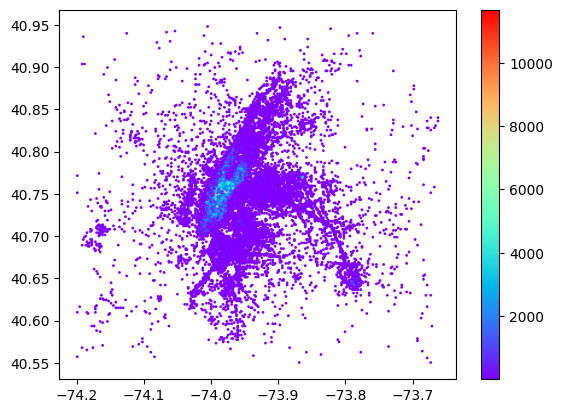

Plotting pickups


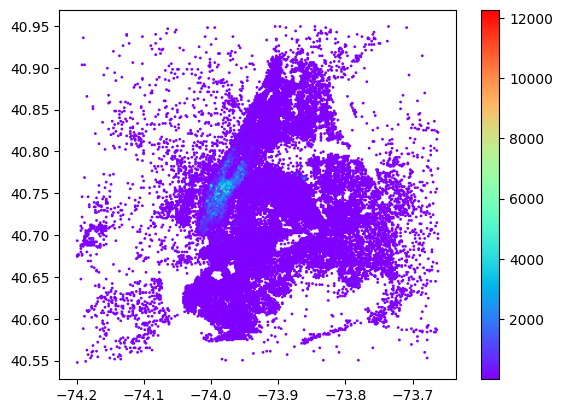

In [ ]:
# Squares of 500 meters
#latitudeStep = 0.004491556
#longitudeStep = 0.005986
#northLatitude = 41.474937 - 0.5 * latitudeStep
#southLatitude = northLatitude - 300 * latitudeStep
#eastLongitude = -74.913585 - 0.5 * longitudeStep
#westLongitude = eastLongitude + 300 * longitudeStep

# Squares of 150 meters
latitudeStep = 0.0013474668
longitudeStep = 0.0017958
northLatitude = 40.95
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.2
westLongitude = eastLongitude + 300 * longitudeStep

# function to round longitude to a point in the middle of the square
def longiRound( val):
    return ((val - eastLongitude) // longitudeStep) * longitudeStep + eastLongitude + longitudeStep / 2
spark.udf.register("longround", longiRound, DoubleType())

# function to round latitude to a point in the middle of the square
def latRound( l):
    return northLatitude - ((northLatitude - l) // latitudeStep) * latitudeStep - latitudeStep / 2
spark.udf.register("latround", latRound, DoubleType())

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")

# Let's filter data outside of the box and build a grid
# Points in each square are mapped to the center of the square.
dataset.createOrReplaceTempView("data")
filteredDataDF = spark.sql( """SELECT medallion, hack_license, pickup_datetime,
                                    dropoff_datetime, trip_time_in_secs, trip_distance,
                                    longround(pickup_longitude) AS pickup_longitude,
                                    latround(pickup_latitude) AS pickup_latitude,
                                    longround(dropoff_longitude) AS dropoff_longitude,
                                    latround(dropoff_latitude) AS dropoff_latitude,
                                    payment_type, fare_amount, mta_tax,
                                    tip_amount, tolls_amount, total_amount
                                  FROM data
                                  WHERE pickup_longitude >= """ + str(eastLongitude) + """ AND
                                  pickup_longitude <=  """ + str(westLongitude) + """ AND
                                  dropoff_longitude >=  """ + str(eastLongitude) + """ AND
                                  dropoff_longitude <=  """ + str(westLongitude) + """ AND
                                  pickup_latitude <= """ + str(northLatitude) + """ AND
                                  pickup_latitude >= """ + str(southLatitude) + """ AND
                                  dropoff_latitude <=  """ + str(northLatitude) + """ AND
                                  dropoff_latitude >=  """ + str(southLatitude))
filteredDataDF.createOrReplaceTempView("data")

# Frequency for pickups
pickupsDF = spark.sql( """SELECT pickup_longitude, pickup_latitude, count(*) AS cnt
                                  FROM data
                                  GROUP BY pickup_longitude, pickup_latitude""")
pickups = pickupsDF.collect()

print('Plotting pickups')
p = plt.scatter([row.pickup_longitude for row in pickups],
            [row.pickup_latitude for row in pickups],
            c=[row.cnt for row in pickups],s=1,cmap="rainbow")
plt.colorbar(p)
plt.show()

# Statistics for pickups
dropoffsDF = spark.sql( """SELECT dropoff_longitude, dropoff_latitude, count(*) AS cnt
                                  FROM data
                                  GROUP BY dropoff_longitude, dropoff_latitude""")
dropoffs = dropoffsDF.collect()

print('Plotting pickups')
p = plt.scatter([row.dropoff_longitude for row in dropoffs],
            [row.dropoff_latitude for row in dropoffs],
            c=[row.cnt for row in dropoffs],s=1,cmap="rainbow")
plt.colorbar(p)
plt.show()



## Exercise 1: simple statistics

Compute, for each license, the total amount of money collected.

Comapre the time it takes to execute the code for Pandas, Spark Pandas API, Spark SQL and cuDF.

**Draw some conclusions** by comparing the time for performing the computation using Spark and Pandas, and also when using the small and long dataset.

### Code: Pandas library

In [ ]:
start_time = time.time()
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

dataset = pd.read_csv(FILENAME,names=mySchema)
result = dataset[["hack_license","total_amount"]].groupby("hack_license").sum()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


### Results (Pandas)

The time to process the small dataset was : 8.356325387954712 seconds.

The time to process the large dataset was : couldn't complete (crashed due to exceeding the available RAM).

### Code: Spark Pandas API

In [ ]:
start_time = time.time()
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

dataset = ps.read_csv(FILENAME,names=mySchema)
result = dataset[["hack_license","total_amount"]].groupby("hack_license").sum()
# force execution
result0 = result.to_spark().collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


Runtime = 1459.8563106060028


### Results (Spark Pandas API)

The time to process the small dataset was : 20.199187755584717 seconds.

The time to process the large dataset was : 1459.8563106060028.

### Spark SQL

In [ ]:
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Group project") \
    .getOrCreate()

start_time = time.time()
mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")
statisticsDF = spark.sql( """SELECT hack_license, SUM(total_amount) AS total_amount FROM data GROUP BY hack_license""")
statistics = statisticsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 560.3911609649658


### Results (Spark)

The time to process the small dataset was : 8.35206937789917 seconds.

The time to process the large dataset was : 560.3911609649658 seconds.

### Code: cuDF

In [ ]:
start_time = time.time()
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

dataset = cudf.read_csv(FILENAME,names=mySchema)
result = dataset[["hack_license","total_amount"]].groupby("hack_license").sum()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 2.590904951095581


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/assignment1/sorted_data.csv.gz" .
!gunzip -k sorted_data.csv.gz
FILENAME = "sorted_data.csv"

In [ ]:
!ls -lh sorted_data.csv

-r-------- 1 root root 32G Apr 21 14:42 sorted_data.csv


In [ ]:
import cudf

start_time = time.time()
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

# Try reading only the first 5 million rows
dataset = cudf.read_csv("sorted_data.csv", names=mySchema, nrows=20_000_000)

# Proceed with the computation on this subset
result = dataset[["hack_license", "total_amount"]].groupby("hack_license").sum()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 9.25938105583191


### Results (cuDF)

The time to process the small dataset was : 2.6398167610168457 seconds.

The time to process the large dataset was : 9.25938105583191 seconds.

### Results discussion

The goal of this exercise was to evaluate the performance of four different data analysis engines — **Pandas**, **Spark Pandas API**, **Spark SQL**, and **cuDF** — in computing the total amount of money collected per taxi license.

#### On the small dataset (135 MB):

- **cuDF** was the fastest, completing the task in just **2.64 seconds**. This is thanks to its GPU acceleration and ability to process data in parallel efficiently. It outperformed all CPU-based solutions.

- **Pandas** and **Spark SQL** delivered very similar performance — **8.36 seconds** and **8.35 seconds**, respectively. This indicates that for smaller data sizes, both engines are fairly efficient. Pandas benefits from its lightweight structure, while Spark SQL benefits from its optimized query execution engine, even without a distributed setup.

- **Spark Pandas API** was significantly slower, taking **20.20 seconds**. This overhead likely comes from the extra internal conversions and abstractions it introduces to maintain Pandas-like syntax on top of Spark, making it inefficient for smaller workloads.

#### On the large dataset (12.3 GB):

- **cuDF** outperformed all methods with an execution time of just **9.25938105583191 seconds**, showcasing the advantage of GPU-based analytics for large-scale data (also needing to unzip the file on this process). We got an error ("*cudaErrorMemoryAllocation out of memory*") when trying to run the full dataset, but we still tested for the first 20 million rows, which is still a big amount of data, and got good results when using cuDF.

- **Spark SQL** successfully completed the task in **589.36 seconds**. While much slower than cuDF, it was the only CPU-based solution that managed to handle the large dataset without failing, demonstrating its scalability in distributed or optimized environments.

- **Spark Pandas API** did complete the processing of the large dataset, taking approximately **1459.86 seconds**, which was significantly slower compared to Spark SQL and cuDF. This long runtime is likely due to the overhead introduced by its hybrid architecture, which translates high-level pandas-like operations into Spark under the hood. This translation is not always optimized for performance, especially in memory-constrained environments like Google Colab, where resource allocation is not distributed across a full cluster.

- **Pandas** failed to complete the operation due to memory limitations, as it is not designed to handle data at this scale in memory-constrained environments.

This exercise highlights the importance of selecting the **right tool for the right context**. For smaller datasets, Pandas and Spark SQL perform well and are easy to work with. However, as data scales, these tools can struggle in resource-constrained environments. When working with large datasets and when GPU infrastructure is available, **cuDF is the best option** for performance and efficiency.

---

#### Key Takeaways:

- **Pandas** is ideal for **quick tasks on small datasets**, but not suitable for larger-scale processing.

- **Spark SQL** provides a **balanced and optimized option**, and would likely scale better if executed in a true distributed cluster.

- **Spark Pandas API** offers familiar syntax for Pandas users but introduces **noticeable overhead** and struggles with larger datasets.

- **cuDF** delivers **exceptional performance on both small and large datasets**, provided there is access to a suitable GPU.

## Exercise 2

The code presented in the **Plotting heatmap** section includes the call to an registered Python UDF function. In this exercise we want to measure the impact of using the UDF function.

Run this exercise with the small dataset.

In [ ]:
start_time = time.time()

# Squares of 150 meters
latitudeStep = 0.0013474668
longitudeStep = 0.0017958
northLatitude = 40.95
southLatitude = northLatitude - 300 * latitudeStep
westLongitude = -74.2
eastLongitude = westLongitude + 300 * longitudeStep

# function to round longitude to a point in the middle of the square
def longiRound( val):
    return ((val - eastLongitude) // longitudeStep) * longitudeStep + eastLongitude + longitudeStep / 2
spark.udf.register("longround", longiRound, DoubleType())

# function to round latitude to a point in the middle of the square
def latRound( l):
    return northLatitude - ((northLatitude - l) // latitudeStep) * latitudeStep - latitudeStep / 2
spark.udf.register("latround", latRound, DoubleType())

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")

# Let's filter data outside of the box and build a grid
# Points in each square are mapped to the center of the square.
dataset.createOrReplaceTempView("data")
filteredDataDF = spark.sql( """SELECT medallion, hack_license, pickup_datetime,
                                    dropoff_datetime, trip_time_in_secs, trip_distance,
                                    longround(pickup_longitude) AS pickup_longitude,
                                    latround(pickup_latitude) AS pickup_latitude,
                                    longround(dropoff_longitude) AS dropoff_longitude,
                                    latround(dropoff_latitude) AS dropoff_latitude,
                                    payment_type, fare_amount, mta_tax,
                                    tip_amount, tolls_amount, total_amount
                                  FROM data
                                  WHERE pickup_longitude >= """ + str(eastLongitude) + """ AND
                                  pickup_longitude <=  """ + str(westLongitude) + """ AND
                                  dropoff_longitude >=  """ + str(eastLongitude) + """ AND
                                  dropoff_longitude <=  """ + str(westLongitude) + """ AND
                                  pickup_latitude <= """ + str(northLatitude) + """ AND
                                  pickup_latitude >= """ + str(southLatitude) + """ AND
                                  dropoff_latitude <=  """ + str(northLatitude) + """ AND
                                  dropoff_latitude >=  """ + str(southLatitude))
filteredDataDF.createOrReplaceTempView("data")

# Frequency for pickups
pickupsDF = spark.sql( """SELECT pickup_longitude, pickup_latitude, count(*) AS cnt
                                  FROM data
                                  GROUP BY pickup_longitude, pickup_latitude""")
pickups = pickupsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 10.767496585845947


**Results (Spark SQL with UDF Python function)**

The time to process the small dataset was : 10.767496585845947 seconds.

Write the code in Spark SQL without using the auxiliary function.

In [ ]:
# TO COMPLETE
start_time = time.time()

# Squares of 150 meters
latitudeStep = 0.0013474668
longitudeStep = 0.0017958
northLatitude = 40.95
southLatitude = northLatitude - 300 * latitudeStep
westLongitude = -74.2
eastLongitude = westLongitude + 300 * longitudeStep

# Recreate filtered data using SQL only (no UDFs)
filteredDataDF = spark.sql(f"""
    SELECT medallion, hack_license, pickup_datetime, dropoff_datetime,
           trip_time_in_secs, trip_distance,
           FLOOR((pickup_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep}/2 AS pickup_longitude,
           FLOOR(({northLatitude} - pickup_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep}/2 + {northLatitude} AS pickup_latitude,
           FLOOR((dropoff_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep}/2 AS dropoff_longitude,
           FLOOR(({northLatitude} - dropoff_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep}/2 + {northLatitude} AS dropoff_latitude,
           payment_type, fare_amount, mta_tax, tip_amount, tolls_amount, total_amount
    FROM data
    WHERE pickup_longitude >= {eastLongitude} AND pickup_longitude <= {westLongitude}
          AND dropoff_longitude >= {eastLongitude} AND dropoff_longitude <= {westLongitude}
          AND pickup_latitude <= {northLatitude} AND pickup_latitude >= {southLatitude}
          AND dropoff_latitude <= {northLatitude} AND dropoff_latitude >= {southLatitude}
""")

filteredDataDF.createOrReplaceTempView("data")

# Frequency for pickups
pickupsDF = spark.sql("""
    SELECT pickup_longitude, pickup_latitude, count(*) AS cnt
    FROM data
    GROUP BY pickup_longitude, pickup_latitude
""")

pickups = pickupsDF.collect()

end_time = time.time()
print("Runtime = " + str(end_time - start_time))



Runtime = 7.66997504234314


**Results (Spark SQL with no UDF Python function)**

The time to process the small dataset was : 7.66997504234314 seconds.




### Discussion of Results

The goal of this exercise was to assess the performance implications of using **Python UDFs** versus **pure Spark SQL expressions** in the context of grid-based coordinate transformations.

We compared two approaches for calculating pickup frequencies in grid cells:

1. **Spark SQL with Python UDFs**  
   Runtime: **10.77 seconds**

2. **Pure Spark SQL (no UDFs)**  
   Runtime: **7.67 seconds**

**Pure Spark SQL outperformed the version using UDFs**, the SQL-only version was approximately 30% faster than the UDF version.. This aligns with common Spark performance best practices, as **UDFs tend to introduce serialization overhead** and **break Spark's query optimization**, which can degrade performance.


#### Final Takeaways

- **Use pure Spark SQL** when possible, especially for grid-based transformations that can be expressed as arithmetic operations.
- **Use UDFs cautiously**, and only when the logic is too complex or unreadable in SQL.


## Exercise 3

Let's start by trying to help the city to identify which new express bus routes shoud introduce. To this end, you should find the 20 most frequent routes whose distance is above a given treshold (defined by you).

For establishing these routes, we suggest that you use a grid of 500m of side.

Write two solutions: one using Spark SQL and the other Spark Pandas API.

In [ ]:
# COMPLETE with Spark SQL

# TO COMPLETE
start_time = time.time()

# Squares of 500 meters
latitudeStep = 0.004491556
longitudeStep = 0.005986
northLatitude = 41.474937 - 0.5 * latitudeStep
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.913585 - 0.5 * longitudeStep
westLongitude = eastLongitude + 300 * longitudeStep

# Set distance threshold
threshold = 2.0  # You can define your own threshold in miles

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")

# Let's filter data outside of the box and build a grid
# Points in each square are mapped to the center of the square.
dataset.createOrReplaceTempView("data")
filteredDataDF = spark.sql(f"""SELECT medallion, hack_license, pickup_datetime,
                                    dropoff_datetime, trip_time_in_secs, trip_distance,
                                    FLOOR((pickup_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep}/2 AS pickup_longitude,
                                    FLOOR(({northLatitude} - pickup_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep}/2 + {northLatitude} AS pickup_latitude,
                                    FLOOR((dropoff_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep}/2 AS dropoff_longitude,
                                    FLOOR(({northLatitude} - dropoff_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep}/2 + {northLatitude} AS dropoff_latitude,
                                    payment_type, fare_amount, mta_tax,
                                    tip_amount, tolls_amount, total_amount
                                  FROM data
                                  WHERE
                                  trip_distance >= {threshold} AND
                                  pickup_longitude >= {eastLongitude} AND
                                  pickup_longitude <=  {westLongitude} AND
                                  dropoff_longitude >=  {eastLongitude} AND
                                  dropoff_longitude <=  {westLongitude} AND
                                  pickup_latitude <= {northLatitude} AND
                                  pickup_latitude >= {southLatitude} AND
                                  dropoff_latitude <=  {northLatitude} AND
                                  dropoff_latitude >=  {southLatitude}""")
filteredDataDF.createOrReplaceTempView("data")

# Top 20 Routes by count above threshold
routesDF = spark.sql( """SELECT pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude,
                                AVG(trip_distance) AS avg_trip_distance, count(*) AS cnt
                                  FROM data
                                  GROUP BY pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude
                                  ORDER BY cnt DESC
                                  LIMIT 20""")
routes = routesDF.collect()

routesDF.show()

end_time = time.time()
print("Runtime = " + str(end_time - start_time))

+----------------+------------------+-----------------+------------------+------------------+---+
|pickup_longitude|   pickup_latitude|dropoff_longitude|  dropoff_latitude| avg_trip_distance|cnt|
+----------------+------------------+-----------------+------------------+------------------+---+
|    -73.87202100|42.166636623999995|     -73.97378300|42.184602847999995| 9.845667166416778|667|
|    -73.98575500|42.180111291999995|     -73.87202100|42.166636623999995|10.837281368821287|526|
|    -73.87202100|42.166636623999995|     -73.97976900|42.180111291999995|10.288673267326738|505|
|    -73.87202100|42.166636623999995|     -73.98575500|42.180111291999995|10.423607214428856|499|
|    -73.87202100|42.166636623999995|     -73.98575500|42.184602847999995|  9.95490981963928|499|
|    -73.87202100|42.166636623999995|     -73.97378300|42.189094403999995| 9.057551867219923|482|
|    -73.97976900|42.180111291999995|     -73.87202100|42.166636623999995|10.398871681415939|452|
|    -73.99174100|42

In [ ]:
# COMPLETE with Spark Pandas API code
import pyspark.pandas as ps
import numpy as np

# TO COMPLETE
start_time = time.time()

# Define the correct schema (like in earlier Spark examples)
columns = [
    "medallion", "hack_license", "pickup_datetime", "dropoff_datetime",
    "trip_time_in_secs", "trip_distance",
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude",
    "payment_type", "fare_amount", "mta_tax",
    "tip_amount", "surcharge", "tolls_amount", "total_amount"
]

# Load CSV with correct headers
df = ps.read_csv(FILENAME, names=columns)

# Define 500m grid parameters
latitudeStep = 0.004491556
longitudeStep = 0.005986
northLatitude = 41.474937 - 0.5 * latitudeStep
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.913585 - 0.5 * longitudeStep
westLongitude = eastLongitude + 300 * longitudeStep

# Define your threshold (miles)
threshold = 2.0  # Can choose different thresold

# Filter based on distance and location thresholds
df_filtered = (
    df[
        (df["trip_distance"] >= threshold) &
        (df["pickup_longitude"].between(eastLongitude, westLongitude)) &
        (df["dropoff_longitude"].between(eastLongitude, westLongitude)) &
        (df["pickup_latitude"].between(southLatitude, northLatitude)) &
        (df["dropoff_latitude"].between(southLatitude, northLatitude))
    ]
    .assign(
        pickup_longitude_center = (np.floor((df["pickup_longitude"] - eastLongitude) / longitudeStep)) * longitudeStep + eastLongitude + longitudeStep / 2,
        pickup_latitude_center = (np.floor((northLatitude - df["pickup_latitude"]) / latitudeStep)) * latitudeStep + northLatitude - latitudeStep / 2,
        dropoff_longitude_center = (np.floor((df["dropoff_longitude"] - eastLongitude) / longitudeStep)) * longitudeStep + eastLongitude + longitudeStep / 2,
        dropoff_latitude_center = (np.floor((northLatitude - df["dropoff_latitude"]) / latitudeStep)) * latitudeStep + northLatitude - latitudeStep / 2,
    )
)


# Group and count
routes_pd = (
    df_filtered
    .groupby(["pickup_longitude_center", "pickup_latitude_center",
              "dropoff_longitude_center", "dropoff_latitude_center"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)
display(routes_pd)

end_time = time.time()
print("Runtime = " + str(end_time - start_time))


/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.11/dist-packages/pyspark/pandas/u

,pickup_longitude_center,pickup_latitude_center,dropoff_longitude_center,dropoff_latitude_center,count
66615,-73.872021,42.166637,-73.973783,42.184603,667
115300,-73.985755,42.180111,-73.872021,42.166637,526
31870,-73.872021,42.166637,-73.979769,42.180111,505
25304,-73.872021,42.166637,-73.985755,42.184603,499
90899,-73.872021,42.166637,-73.985755,42.180111,499
50933,-73.872021,42.166637,-73.973783,42.189094,482
105434,-73.979769,42.180111,-73.872021,42.166637,452
34057,-73.991741,42.189094,-73.955825,42.175620,428
70703,-73.973783,42.184603,-73.872021,42.166637,424
34741,-73.872021,42.166637,-73.979769,42.175620,421


Runtime = 61.60497498512268


#### Discussion

The goal of this exercise is to identify the 20 most common taxi routes that exceed a given distance threshold (e.g., 2.0 miles). To do this, pickup and dropoff coordinates are rounded to the centers of 500-meter grid squares. Routes are defined based on these rounded coordinates, and the most frequent ones are returned.

#### Common Setup:

Both methods use the same geographic grid logic:
- Grid cells are 500 meters by 500 meters.
- The latitude and longitude steps are set to approximate that size.
- The city is represented by a grid that spans 300 x 300 squares.
- The threshold for including a trip is a minimum trip distance of 2.0 miles (as determined by common distances between stops on express bus routes).

#### Spark SQL Solution:

This approach rounds latitude and longitude values to the centers of grid squares, then process—filters trips within the bounding box, applying the distance threshold, grouping by rounded coordinates, and aggregating using Spark SQL functions.

This method benefits from Spark's Catalyst optimizer, which makes the SQL execution efficient. The end-to-end runtime for this method was about **29.53 seconds.**

#### Spark Pandas API Solution:

This solution uses the Spark Pandas API to apply similar filtering and transformation logic using a pandas-like syntax. It uses NumPy operations to compute the rounded coordinates and then groups and counts the most frequent routes using typical pandas methods.

While easier to write for those familiar with pandas, this method is slower and incurs more overhead. The runtime was approximately **61.60 seconds,** more than twice as long as the Spark SQL approach.

#### Key Takeaways:

* Both methods produce the **same resulting routes.**
* However, **Spark SQL** is **significantly faster** and **more optimized for large-scale processing**, better suited for production workflows or performance-critical applications.
* On the other hand, the **Spark Pandas API** is easier to use for those with a pandas background and can be a good option for **prototyping** or **working with smaller datasets.**

In summary, use **Spark SQL** when **performance and scalability** matter, and consider the **Spark Pandas API** when **development speed or simplicity** is the priority.

## Exercise 4

This question intends to define the location of taxi ranks / taxi stand (the places where taxis stop waiting for collecting clients) in a way that tries to minimize the distance a client needs to walk to reach a taxi rank.

Run this exercise with the small dataset and compare the execution time when using scikit-learn, cuML and Spark MLib.

**Note:** This dataset is for NYC taxis. So, pickups outside of the city are infrequent and not representative of the demand in such areas. As such, you should focus on pickups in a square that includes NYC (it is ok if the square includes parts outside of the city). Use, for example, the following square:
```
northLatitude = 40.86
southLatitude = 40.68
westLongitude = -74.03
eastLongitude = -73.92
```

**Suggestion:** Plot your results as a heatmap, with the color being a measurement of the value of the taxi rank.

In [ ]:
# Bounding box
northLatitude = 40.86
southLatitude = 40.68
westLongitude = -74.03
eastLongitude = -73.92

import pandas as pd
import numpy as np

# Columns: pickup_longitude, pickup_latitude
# Define the correct schema (like in earlier Spark examples)
columns = [
    "medallion", "hack_license", "pickup_datetime", "dropoff_datetime",
    "trip_time_in_secs", "trip_distance",
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude",
    "payment_type", "fare_amount", "mta_tax",
    "tip_amount", "surcharge", "tolls_amount", "total_amount"
]

# Load dataset
df = pd.read_csv(FILENAME, names=columns)

# Filter to NYC bounding box
nyc_df = df[
    (df['pickup_latitude'].between(southLatitude, northLatitude)) &
    (df['pickup_longitude'].between(westLongitude, eastLongitude))
]

# Extract coordinates
coords = nyc_df[['pickup_longitude', 'pickup_latitude']].to_numpy()

In [ ]:
# COMPLETE with code using scikit-learn

from sklearn.cluster import KMeans
import time

K = 20  # number of taxi ranks (can adjust)

start = time.time()

kmeans_sklearn = KMeans(n_clusters=K, random_state=42).fit(coords)
labels = kmeans_sklearn.labels_
centroids = kmeans_sklearn.cluster_centers_

end = time.time()
print(f"Scikit-learn execution time: {end - start:.2f}s")

Scikit-learn execution time: 6.19s


In [ ]:
# COMPLETE with code using cuML

from cuml.cluster import KMeans as cuKMeans
import cuml
import cupy as cp

coords_gpu = cp.asarray(coords)

start = time.time()

kmeans_cuml = cuKMeans(n_clusters=K, random_state=42)
kmeans_cuml.fit(coords_gpu)

centroids_gpu = kmeans_cuml.cluster_centers_.get()
labels_gpu = kmeans_cuml.labels_.get()

end = time.time()
print(f"cuML execution time: {end - start:.2f}s")


cuML execution time: 2.22s


In [ ]:
# COMPLETE with code using Spark Mlib

from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import SparkSession
import time

#spark = SparkSession.builder.getOrCreate()
# **(1) Increase Driver Memory:**
spark = SparkSession.builder \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Convert to Spark DataFrame
spark_df = spark.createDataFrame(nyc_df[['pickup_longitude', 'pickup_latitude']])

# Assemble features
vec_assembler = VectorAssembler(inputCols=['pickup_longitude', 'pickup_latitude'], outputCol='features')
spark_df_vec = vec_assembler.transform(spark_df)

start = time.time()

kmeans = SparkKMeans(k=K, seed=42)
model = kmeans.fit(spark_df_vec)
predictions = model.transform(spark_df_vec)
centers_spark = model.clusterCenters()

end = time.time()
print(f"Spark MLlib execution time: {end - start:.2f}s")

Spark MLlib execution time: 44.76s


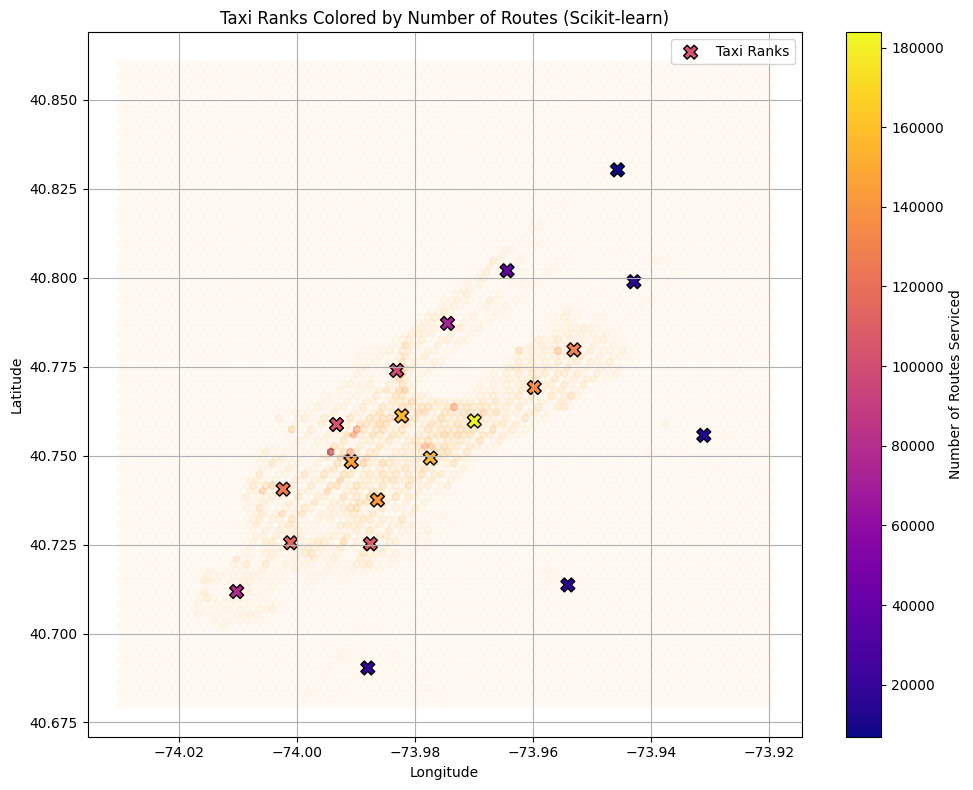

In [ ]:
# Visualize with Heatmap

# Count the number of points assigned to each cluster
counts = np.bincount(labels, minlength=K)

# Colormap mapping
cmap = plt.cm.plasma
colors = cmap(counts)

# Plot heatmap and centroids
plt.figure(figsize=(10, 8))
plt.hexbin(coords[:, 0], coords[:, 1], gridsize=100, cmap='OrRd', alpha=0.5)
sc = plt.scatter(centroids[:, 0], centroids[:, 1], c=counts, cmap='plasma', s=100, marker='X', edgecolor='black', label='Taxi Ranks')
plt.colorbar(sc, label='Number of Routes Serviced')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Taxi Ranks Colored by Number of Routes (Scikit-learn)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Execution times:**

scikit-learn: 6.19s

cuML: 2.22s

Spark Mlib: 44.76s


#### Discussion

The goal of this exercise was to evaluate the performance of three different approaches, **scikit-learn, cuML, and Spark MLlib,** in a **clustering** task.

##### Process:

We started by loading the dataset and filtering to select only trips starting in NYC (using the bounding box coordinates provided). Because loading, filtering, and transforming are analyzed in earlier exercises, we did not include this in the runtime calculation. Pandas .readcsv() was used due to simplicity and readability.

KMeans is a good choice for this problem because it provides a fixed number of meaningful, central locations that minimize walking distance from real pickup hotspots, with scalability, interpretability, and solid results in 2D space. By default, the KMeans methods utilize Euclidean distance, which is reasonable for this specific problem. Minimizing Manhattan distance was also considered, but because the latitude/longitude grid does not actually match the street grid, it was unclear that Manhattan would be meaningfully better, despite the name.

We chose **K=20** for the clustering. Although an elbow graph was analyzed, there was no clear elbow point. In the context of the problem, the more taxi stands that can be established, the less a customer would need to walk to reach a taxi stand. However in real-world contexts, there are costs, parking space availability, zoning rules, and taxi supply numbers that would need to be considered to effectively optimize the number of clusters, K.

#### Runtimes:

**Scikit-learn** was reasonably fast (**6.19s**), which is expected for a small-medium dataset like this one. Although the operations are optimized, they are **CPU-based** and **not parallelized**. We can expect that scikit-learn will scale linearly (or worse) and therefore **fail with larger datasets**.

**cuML** (customer ML) was fast (**2.22s**), which was expected. Because cuML is **GPU-accelerated** and **parallelized** we would expect it to remain fast for even larger datasets, assuming GPU memory allows it.

**Spark MLlib** was the slowest in this instance (**44.76s**), which was expected for this relatively small, low-dimensional dataset. Spark MLlib **requires significant overhead** for the coordination of **distributed executors** and **task schedulers**, as well as the **shuffling**. Additionally, if intermediate results are written on the disk or cached memory, that can lead to more complexity and inefficiency. However, we would expect Spark MLlib to perform well for large and very large data sets which would exceed the RAM or GPU.

#### Cluster Heatmap:

The heatmap shown plots the clusters as determined by scikit-learn, where the color of the taxi rank corresponds to the number of trips it can serve. It is important to note that the map includes taxi ranks outside of Manhattan due to the initial latitude/longitude boundaries provided which do not match the specific borders of Manhattan. If we were to plot heatmaps for each method, we might observe slight differences due to differences in initialization and computing precision, though they should be relatively similar.

#### Key Takeaways

* **KMeans** is **well-suited** for this problem because it finds optimal locations (centroids) to **minimize average client walking distance**.
* **Scikit-learn** provides good performance for **small** datasets, but **does not scale efficiently** due to its single-threaded, CPU-based nature.
* **cuML** is **ideal** for low-dimensional, GPU-compatible data, offering excellent performance with minimal overhead.
* **Spark MLlib** introduces **significant overhead for small datasets** but is built for distributed scalability on large datasets that exceed memory limits of a single machine.
* When using clustering to plan infrastructure (like taxi stands), it’s important to weigh not just mathematical optimality but also **real-world constraints** like zoning laws and space availability.
* Visualizing cluster results (e.g. heatmaps with centroid values) helps in interpreting and communicating model output to stakeholders.